## **Handling Missing Numerical Data** 
In this we only discuss SimpleImputer Class

### Roadmap
- **1. Environment Setup & Data Preparation**
- **2. Mean and Median Imputation**
  - 2.1 Concept & Overview
  - 2.2 Scikit-Learn Implementation
  - 2.3 Assessing Impact on Variance & Distribution
  - 2.4 Key Revision Notes
- **3. Arbitrary Value Imputation**
  - 3.1 Concept & Overview
  - 3.2 Scikit-Learn Implementation
  - 3.3 Assessing Impact on Variance & Distribution
  - 3.4 Key Revision Notes

## **1. Environment Setup & Data Preparation**

Load necessary libraries, inspect missing data ratios, and perform a train-test split prior to imputation to prevent **data leakage**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Load dataset
df = pd.read_csv('docs/Lecture-023-titanic_toy.csv')

# Inspect missing value ratios
print("Missing Value Ratios:")
print(df.isnull().mean())

# Feature-Target split
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


Missing Value Ratios:
Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

Train Shape: (712, 3), Test Shape: (179, 3)


## **2. Mean and Median Imputation**

### **2.1 Concept & Overview**

- **What:** Replaces missing values ($NaN$) with the mean or median calculated from the training set.
- **Why:** Preserves sample size without dropping missing rows.
- **When:** Used when data is Missing Completely at Random (MCAR) and total missingness is low ($< 5\%$).
  - Use **Mean** when feature distribution is symmetric (Gaussian).
  - Use **Median** when feature distribution is skewed or contains outliers.

### **2.2 Scikit-Learn Implementation**

We use `SimpleImputer` inside `ColumnTransformer`. `set_output(transform="pandas")` ensures Scikit-Learn returns structured Pandas DataFrames directly.

In [2]:
# Define SimpleImputer transformers
imputer_median = SimpleImputer(strategy='median')
imputer_mean = SimpleImputer(strategy='mean')

# Construct ColumnTransformer
trf_mean_median = ColumnTransformer([
    ('age_median', imputer_median, ['Age']),
    ('fare_mean', imputer_mean, ['Fare'])
], remainder='passthrough', verbose_feature_names_out=False)

# Configure pipeline to return DataFrame output directly
trf_mean_median.set_output(transform="pandas")

# Fit on training set, transform both train and test splits
X_train_imputed = trf_mean_median.fit_transform(X_train)
X_test_imputed = trf_mean_median.transform(X_test)

# Display learned statistics
print("Learned Median (Age):", trf_mean_median.named_transformers_['age_median'].statistics_[0])
print("Learned Mean (Fare):  ", trf_mean_median.named_transformers_['fare_mean'].statistics_[0])
X_train_imputed.head()

Learned Median (Age): 28.75
Learned Mean (Fare):   32.61759689349112


,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0


### **2.3 Assessing Impact on Variance & Distribution**

Mean/Median imputation artificially increases data density at central points, shrinking original feature variance.

=== Variance Comparison ===
Original Age Variance:        204.3495133904614
Imputed Age Variance (Median): 161.9895663346054
Original Fare Variance:       2448.197913706318
Imputed Fare Variance (Mean):  2324.2385256705547


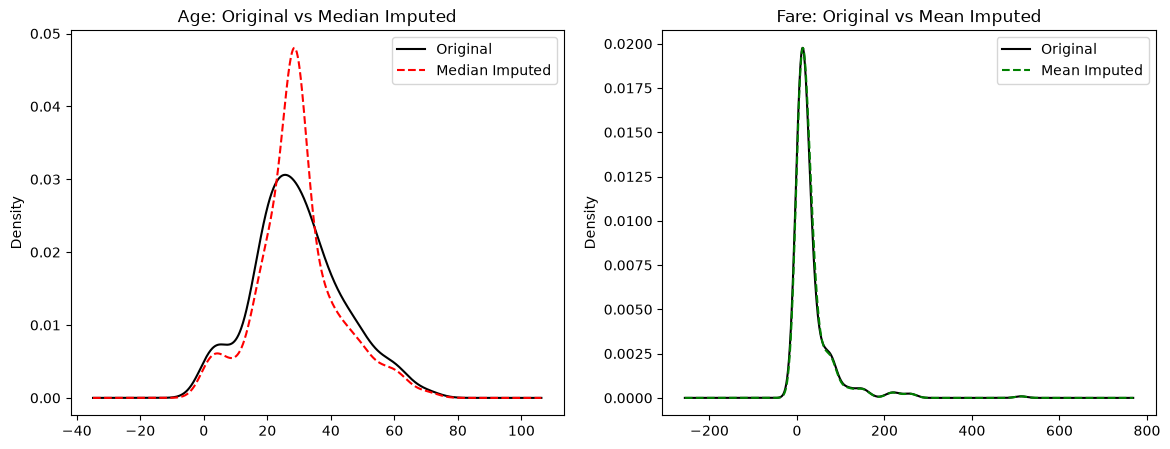

In [3]:
# Compare Variance
print("=== Variance Comparison ===")
print("Original Age Variance:       ", X_train['Age'].var())
print("Imputed Age Variance (Median):", X_train_imputed['Age'].var())
print("Original Fare Variance:      ", X_train['Fare'].var())
print("Imputed Fare Variance (Mean): ", X_train_imputed['Fare'].var())

# Plot Distribution Shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_train['Age'].plot(kind='kde', ax=axes[0], color='black', label='Original')
X_train_imputed['Age'].plot(kind='kde', ax=axes[0], color='red', linestyle='--', label='Median Imputed')
axes[0].set_title('Age: Original vs Median Imputed')
axes[0].legend()

X_train['Fare'].plot(kind='kde', ax=axes[1], color='black', label='Original')
X_train_imputed['Fare'].plot(kind='kde', ax=axes[1], color='green', linestyle='--', label='Mean Imputed')
axes[1].set_title('Fare: Original vs Mean Imputed')
axes[1].legend()

plt.show()

### **2.4 Key Revision Notes**

- **Assumptions:** Data must be Missing Completely at Random (MCAR) with low missingness ratios ($< 5\%$).
- **Advantages:** Simple to implement, computationally efficient, and keeps sample sizes intact.
- **Disadvantages:**
  - Shrinks feature variance artificially.
  - Distorts original probability density by creating tall spikes at central values.
  - Distorts covariance and linear relationships with other variables.
- **Selection Rule:** Use **Mean** for normal distributions; use **Median** for skewed distributions containing outliers.

## **3. Arbitrary Value Imputation**

### **3.1 Concept & Overview**

- **What:** Replaces missing values ($NaN$) with a specific, pre-determined constant value (e.g., `-1`, `99`, `-999`).
- **Why:** Flags missingness explicitly when missing values hold structural meaning.
- **When:** Used when data is Not Missing at Random (NMAR) or when feeding tree-based models (e.g., Decision Trees, XGBoost) that can split effectively on constant flag values.

### **3.2 Scikit-Learn Implementation**

We use `SimpleImputer(strategy='constant', fill_value=...)` to inject target out-of-bounds constants into missing locations.

In [4]:
# Define Constant SimpleImputer transformers
imputer_age_arb = SimpleImputer(strategy='constant', fill_value=-1)
imputer_fare_arb = SimpleImputer(strategy='constant', fill_value=-999)

# Construct ColumnTransformer
trf_arbitrary = ColumnTransformer([
    ('age_minus1', imputer_age_arb, ['Age']),
    ('fare_minus999', imputer_fare_arb, ['Fare'])
], remainder='passthrough', verbose_feature_names_out=False)

trf_arbitrary.set_output(transform="pandas")

# Fit on training set, transform both train and test splits
X_train_arb = trf_arbitrary.fit_transform(X_train)
X_test_arb = trf_arbitrary.transform(X_test)

X_train_arb.head()

,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0


### **3.3 Assessing Impact on Variance & Distribution**

Arbitrary value imputation creates distinct secondary modes (peaks) in the distribution outside the feature's natural domain range.

=== Variance Comparison ===
Original Age Variance:          204.3495133904614
Imputed Age Variance (fill -1):  318.0896202624484
Original Fare Variance:         2448.197913706318
Imputed Fare Variance (fill -999): 53485.010077720224


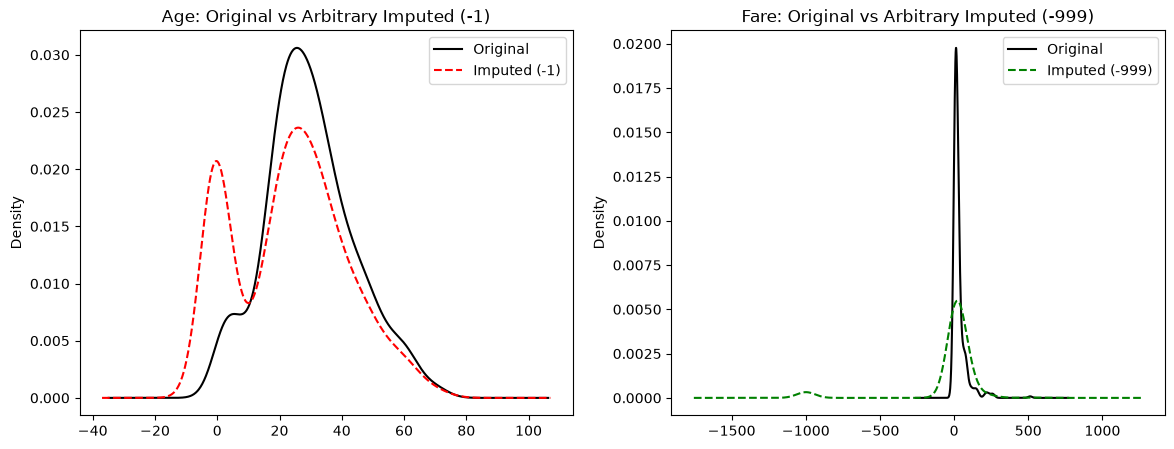

In [5]:
# Compare Variance
print("=== Variance Comparison ===")
print("Original Age Variance:         ", X_train['Age'].var())
print("Imputed Age Variance (fill -1): ", X_train_arb['Age'].var())
print("Original Fare Variance:        ", X_train['Fare'].var())
print("Imputed Fare Variance (fill -999):", X_train_arb['Fare'].var())

# Plot Distribution Shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_train['Age'].plot(kind='kde', ax=axes[0], color='black', label='Original')
X_train_arb['Age'].plot(kind='kde', ax=axes[0], color='red', linestyle='--', label='Imputed (-1)')
axes[0].set_title('Age: Original vs Arbitrary Imputed (-1)')
axes[0].legend()

X_train['Fare'].plot(kind='kde', ax=axes[1], color='black', label='Original')
X_train_arb['Fare'].plot(kind='kde', ax=axes[1], color='green', linestyle='--', label='Imputed (-999)')
axes[1].set_title('Fare: Original vs Arbitrary Imputed (-999)')
axes[1].legend()

plt.show()

### **3.4 Key Revision Notes**

- **Assumptions:** Appropriate when missingness carries explicit structural meaning or predictive power.
- **Advantages:** Preserves missingness pattern explicitly without adding noise to valid distribution ranges.
- **Disadvantages:** Severely inflates or distorts feature variance and PDF curves.
- **Model Compatibility:**
  - **Suitable:** Tree-based models (Decision Trees, Random Forests, XGBoost, LightGBM).
  - **Unsuitable:** Linear models (Linear/Logistic Regression) and distance-based algorithms (KNN, SVM, K-Means), as arbitrary far-off values skew weights and distance metrics.
- **Rule of Thumb:** Always pick an arbitrary constant well outside the feature's operational min-max boundaries (e.g., `-1` for strictly non-negative features like Age or Fare).